# Benchmark Es5A vs Es5B (Random Team vs DP)
Questo notebook compila `es5A.c` e `es5B.c`, genera istanze casuali con candidati ordinati nello stesso input e confronta i tempi di esecuzione delle due versioni.

In [1]:
import subprocess
from pathlib import Path

root = Path('.').resolve()
src_a = root / 'es5A.c'
src_b = root / 'es5B.c'
exe_a = root / 'es5A'
exe_b = root / 'es5B'

if not src_a.exists() or not src_b.exists():
    raise FileNotFoundError('Servono es5A.c e es5B.c nella stessa cartella del notebook')

print('Compilazione in corso...')
subprocess.run(['gcc', '-O2', '-w', str(src_a), '-o', str(exe_a)], check=True)
subprocess.run(['gcc', '-O2', '-w', str(src_b), '-o', str(exe_b)], check=True)
print('Compilazione completata')

Compilazione in corso...
Compilazione completata


In [2]:
import random
import time
import statistics
import subprocess

rng = random.Random(42)

def gen_test(C, P, a_max=1000, k_max=1000):
    candidates = []
    for _ in range(C):
        a = rng.randint(1, a_max)
        k = rng.randint(1, k_max)
        candidates.append((a, k))

    input_data = f'{C} {P}\n'
    for a, k in candidates:
        input_data += f'{a} {k}\n'
    return input_data

def measure_once(exe_path, input_data):
    t0 = time.perf_counter()
    p = subprocess.Popen(
        [str(exe_path)],
        stdin=subprocess.PIPE,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        text=True
    )
    p.communicate(input_data)
    return time.perf_counter() - t0

def measure(exe_path, input_data, repeats=5, warmup=2):
    for _ in range(warmup):
        measure_once(exe_path, input_data)

    samples = [measure_once(exe_path, input_data) for _ in range(repeats)]
    return statistics.median(samples)

In [ ]:
sizes4test = list(range(20, 221, 20))
datasets = {}
timesA = []
timesB = []

print('Avvio benchmark...')
for C in sizes4test:
    P = max(1, C // 2)
    data = gen_test(C, P)
    datasets[C] = data

    tA = measure(exe_a, data, repeats=3, warmup=1)
    tB = measure(exe_b, data, repeats=3, warmup=1)
    timesA.append(tA)
    timesB.append(tB)

    print(f'C={C:3d}, P={P:3d} -> es5A={tA*1000:8.3f} ms | es5B={tB*1000:8.3f} ms')

print('Benchmark completato')

Avvio benchmark...
C= 20, P= 10 -> es5A= 355.228 ms | es5B=   8.488 ms
C= 40, P= 20 -> es5A=35975.919 ms | es5B=   6.340 ms
C= 60, P= 30 -> es5A=54808.759 ms | es5B=   6.062 ms
C= 80, P= 40 -> es5A=72579.679 ms | es5B=   5.475 ms
C=100, P= 50 -> es5A=89005.664 ms | es5B=   8.146 ms
C=120, P= 60 -> es5A=106005.761 ms | es5B=   6.784 ms
C=140, P= 70 -> es5A=122319.999 ms | es5B=   5.640 ms
C=160, P= 80 -> es5A=141741.257 ms | es5B=  10.981 ms
C=180, P= 90 -> es5A=157737.238 ms | es5B=   8.642 ms
C=200, P=100 -> es5A=175373.613 ms | es5B=  17.060 ms
C=220, P=110 -> es5A=193509.932 ms | es5B=   8.365 ms
Benchmark completato


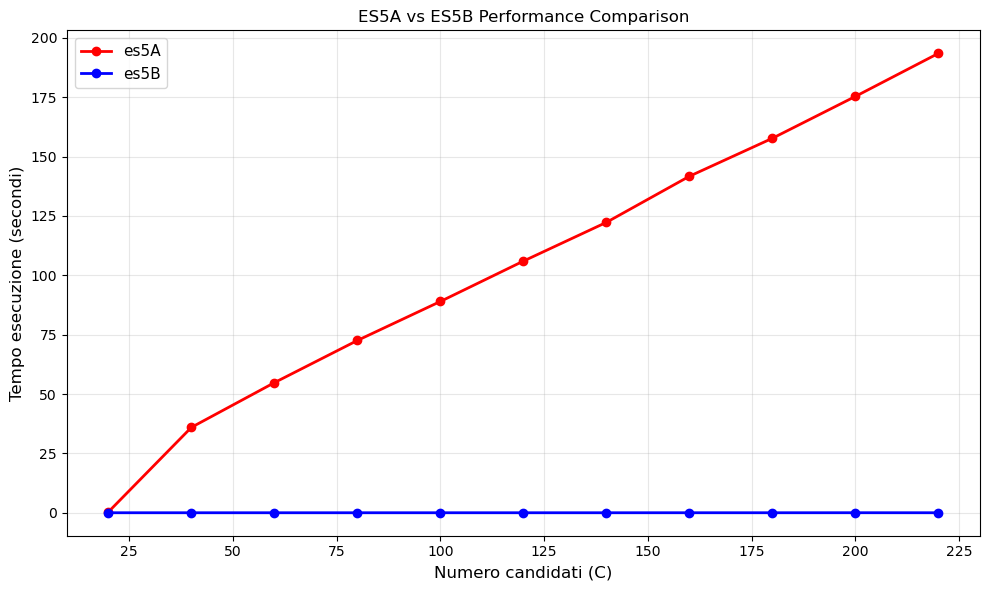

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sizes4test, timesA, label='es5A', color='red', marker='o', linewidth=2)
plt.plot(sizes4test, timesB, label='es5B', color='blue', marker='o', linewidth=2)
plt.xlabel('Numero candidati (C)', fontsize=12)
plt.ylabel('Tempo esecuzione (secondi)', fontsize=12)
plt.title('ES5A vs ES5B Performance Comparison')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Megatest su es5B con raccolta tempi per il grafico
import subprocess
import time

def gen_test_massive(C, P):
    return gen_test(C, P)

print('=== TEST GIGANTE SU ES5B ===')
huge_sizes = range(10000,100000,5000)
results = []

for C in huge_sizes:
    P = max(1, C // 2)
    data = gen_test_massive(C, P)

    start = time.time()
    try:
        p = subprocess.run([str(exe_b)], input=data.encode(), capture_output=True, timeout=600)
        elapsed = time.time() - start
        if p.returncode != 0:
            print(f'C={C:>5}, P={P:>5} -> STOP (returncode={p.returncode})')
            break
        results.append((C, elapsed))
        print(f'C={C:>5}, P={P:>5} -> {elapsed:.3f} s, returncode={p.returncode}')
    except subprocess.TimeoutExpired:
        print(f'C={C:>5}, P={P:>5} -> TIMEOUT after 600 s')
        break

=== TEST GIGANTE SU ES5B ===
C=10000, P= 5000 -> 0.271 s, returncode=0
C=15000, P= 7500 -> 0.480 s, returncode=0
C=20000, P=10000 -> 0.907 s, returncode=0
C=25000, P=12500 -> 1.295 s, returncode=0
C=30000, P=15000 -> 1.998 s, returncode=0
C=35000, P=17500 -> 2.546 s, returncode=0
C=40000, P=20000 -> 3.511 s, returncode=0
C=45000, P=22500 -> 4.605 s, returncode=0
C=50000, P=25000 -> 5.937 s, returncode=0
C=55000, P=27500 -> 10.413 s, returncode=0
C=60000, P=30000 -> 6.890 s, returncode=-9
C=65000, P=32500 -> 6.402 s, returncode=-9
C=70000, P=35000 -> 7.256 s, returncode=-9
C=75000, P=37500 -> 9.581 s, returncode=-9
C=80000, P=40000 -> 8.910 s, returncode=-9
C=85000, P=42500 -> 11.601 s, returncode=-9
C=90000, P=45000 -> 52.264 s, returncode=-9
C=95000, P=47500 -> 9.412 s, returncode=-9


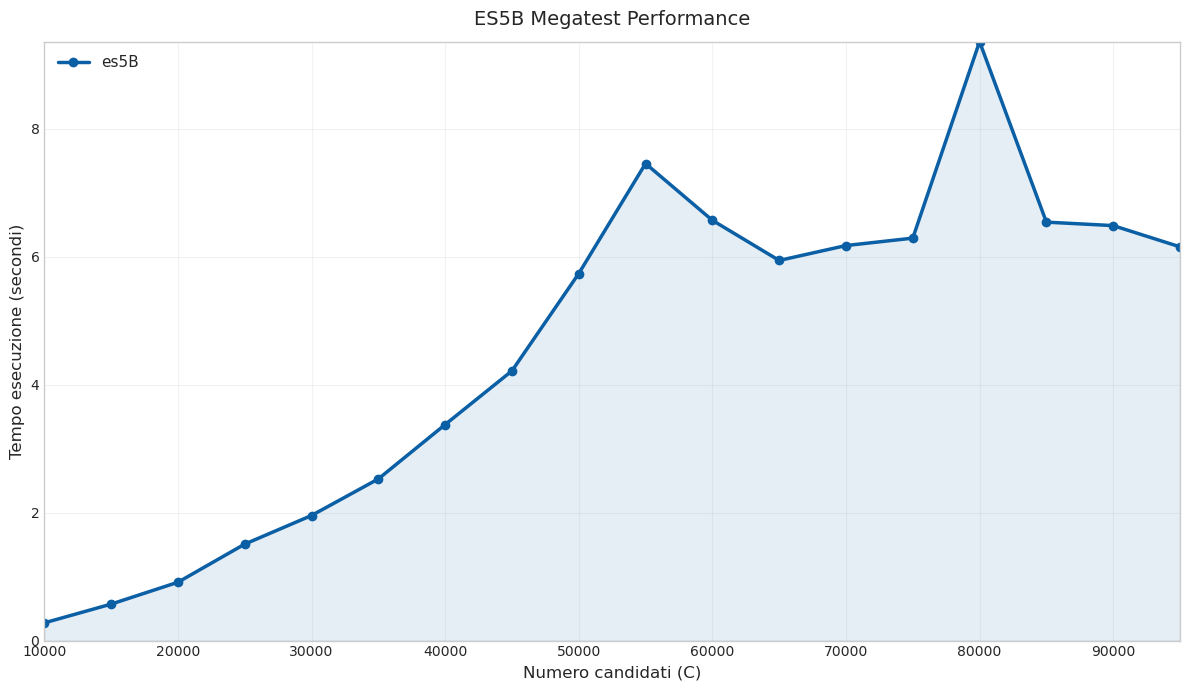

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

if len(results) == 0:
    print('Nessun risultato disponibile per il grafico.')
else:
    plot_C = [c for c, _ in results]
    plot_times = [t for _, t in results]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.plot(plot_C, plot_times, color='#0b5fa5', marker='o', markersize=6, linewidth=2.5, label='es5B')
    ax.fill_between(plot_C, plot_times, color='#0b5fa5', alpha=0.10)
    ax.set_xlabel('Numero candidati (C)', fontsize=12)
    ax.set_ylabel('Tempo esecuzione (secondi)', fontsize=12)
    ax.set_title('ES5B Megatest Performance', fontsize=14, pad=12)
    ax.legend(fontsize=11, loc='upper left')
    ax.grid(True, which='major', alpha=0.25)

    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='both', labelsize=10)
    ax.autoscale(enable=True, axis='both', tight=True)
    ax.annotate('test interrotto al primo fallimento', xy=(0.02, 0.98), xycoords='axes fraction', fontsize=10, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()